In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [12]:
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

print(f"Array shape: {driver_tips.shape}")
print(f"Zero tips: {np.sum(driver_tips == 0)}")
print(f"Non-zero tips: {np.sum(driver_tips > 0)}")
print(f"Mean: ${np.mean(driver_tips):.4f}")
print(f"Median: ${np.median(driver_tips):.4f}")


Array shape: (250,)
Zero tips: 100
Non-zero tips: 150
Mean: $2.7691
Median: $0.7553


In [13]:
np.random.seed(42)

# Bootstrap parameters
n_iterations = 10_000
n = len(driver_tips)
bootstrap_medians = np.empty(n_iterations)

# Manual bootstrap loop — resampling with replacement
for i in range(n_iterations):
    resample = driver_tips[np.random.randint(0, n, size=n)]
    bootstrap_medians[i] = np.median(resample)

# 95% Confidence Interval via percentile method
ci_lower, ci_upper = np.percentile(bootstrap_medians, [2.5, 97.5])
observed_median = np.median(driver_tips)

print(f"Observed Median:       ${observed_median:.4f}")
print(f"Bootstrap 95% CI:      [${ci_lower:.4f}, ${ci_upper:.4f}]")
print(f"Lower margin:          ${observed_median - ci_lower:.4f}")
print(f"Upper margin:          ${ci_upper - observed_median:.4f}")

# Asymmetry discussion
print("""
Asymmetry Discussion:
A parametric CI assumes a symmetric normal sampling distribution, producing
equal lower/upper margins around the point estimate. Here the bootstrap CI is
asymmetric: the upper tail stretches further than the lower tail. This reflects
the true geometry of the data — the 40% zero-mass floors the median near zero
and caps downside variability, while the heavy right skew of the exponential
component allows occasional resamples to pull the median meaningfully higher.
The bootstrap captures this without any distributional assumption.
""")

Observed Median:       $0.7553
Bootstrap 95% CI:      [$0.2643, $1.3636]
Lower margin:          $0.4911
Upper margin:          $0.6082

Asymmetry Discussion:
A parametric CI assumes a symmetric normal sampling distribution, producing
equal lower/upper margins around the point estimate. Here the bootstrap CI is
asymmetric: the upper tail stretches further than the lower tail. This reflects
the true geometry of the data — the 40% zero-mass floors the median near zero
and caps downside variability, while the heavy right skew of the exponential
component allows occasional resamples to pull the median meaningfully higher.
The bootstrap captures this without any distributional assumption.



In [14]:
np.random.seed(42)

# Control: Normal distribution (stable delivery times)
control = np.random.normal(loc=35, scale=5, size=500)

# Treatment: Log-Normal distribution (crash loops → extreme outliers)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

# Observed difference in means (Control - Treatment)
observed_diff = np.mean(control) - np.mean(treatment)

print(f"Control   mean: {np.mean(control):.4f} min")
print(f"Treatment mean: {np.mean(treatment):.4f} min")
print(f"Observed difference (Control - Treatment): {observed_diff:.4f} min")


Control   mean: 35.0342 min
Treatment mean: 32.7692 min
Observed difference (Control - Treatment): 2.2650 min


In [15]:
combined = np.concatenate([control, treatment])

n_permutations = 5_000
perm_diffs = np.empty(n_permutations)

for i in range(n_permutations):
    shuffled = np.random.permutation(combined)
    perm_diffs[i] = np.mean(shuffled[:500]) - np.mean(shuffled[500:])

# Exact empirical p-value: proportion of permutations >= observed difference
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"Observed difference:  {observed_diff:.4f} min")
print(f"Permutation p-value:  {p_value:.4f}")
print(f"Significant (α=0.05): {p_value < 0.05}")


Observed difference:  2.2650 min
Permutation p-value:  0.0004
Significant (α=0.05): True


In [16]:
data = np.genfromtxt('swiftcart_loyalty.csv', delimiter=',', skip_header=1)

subscriber    = data[:, 0]
post_spend    = data[:, 4]

subscribers     = post_spend[subscriber == 1]
non_subscribers = post_spend[subscriber == 0]

mean_sub    = np.mean(subscribers)
mean_nonsub = np.mean(non_subscribers)
sdo         = mean_sub - mean_nonsub

print(f"Subscribers     (D=1) n={len(subscribers)}:  mean post-spend = ${mean_sub:.4f}")
print(f"Non-Subscribers (D=0) n={len(non_subscribers)}: mean post-spend = ${mean_nonsub:.4f}")
print(f"Naive SDO (D=1 - D=0):  ${sdo:.4f}  ({sdo/mean_nonsub*100:.1f}% difference)")
print()
print("The SDO naively supports the marketing team's claim, but this figure is")
print("contaminated by selection bias — power users self-select into SwiftPass,")
print("so we are comparing fundamentally different types of users, not measuring")
print("the true causal effect of the subscription itself.")

Subscribers     (D=1) n=4200:  mean post-spend = $74.0436
Non-Subscribers (D=0) n=4741: mean post-spend = $56.4729
Naive SDO (D=1 - D=0):  $17.5707  (31.1% difference)

The SDO naively supports the marketing team's claim, but this figure is
contaminated by selection bias — power users self-select into SwiftPass,
so we are comparing fundamentally different types of users, not measuring
the true causal effect of the subscription itself.


In [17]:
data = np.genfromtxt('swiftcart_loyalty.csv', delimiter=',', skip_header=1)

subscriber     = data[:, 0]
pre_spend      = data[:, 1]
account_age    = data[:, 2]
support_tickets= data[:, 3]
post_spend     = data[:, 4]

# Covariates matrix (pre-treatment only)
X = np.column_stack([pre_spend, account_age, support_tickets])

# ── 1. Estimate Propensity Scores via Logistic Regression ─────────────────────
lr = LogisticRegression(max_iter=1000)
lr.fit(X, subscriber)
propensity_scores = lr.predict_proba(X)[:, 1]

# ── 2. Nearest Neighbor Matching on Propensity Score ──────────────────────────
treated_idx   = np.where(subscriber == 1)[0]
control_idx   = np.where(subscriber == 0)[0]

ps_treated = propensity_scores[treated_idx].reshape(-1, 1)
ps_control = propensity_scores[control_idx].reshape(-1, 1)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(ps_control)
_, indices = nn.kneighbors(ps_treated)

matched_control_idx = control_idx[indices.flatten()]

# ── 3. Calculate ATT ───────────────────────────────────────────────────────────
post_treated         = post_spend[treated_idx]
post_matched_control = post_spend[matched_control_idx]

att = np.mean(post_treated - post_matched_control)
sdo = np.mean(post_spend[subscriber == 1]) - np.mean(post_spend[subscriber == 0])

print(f"Naive SDO:                      ${sdo:.4f}")
print(f"Causal ATT (PSM):               ${att:.4f}")
print(f"Selection bias component:       ${sdo - att:.4f}")
print()
print("""Analysis:
The naive SDO of ${:.2f} overstates SwiftPass's true effect by attributing
pre-existing power-user behaviour to the subscription itself. After matching
each subscriber to a non-subscriber with an identical propensity to join,
the ATT isolates the pure causal effect at ${:.2f}. The difference of ${:.2f}
is pure selection bias — spending that would have occurred regardless of
the subscription. The marketing team's budget case should be re-evaluated
against the ATT, not the SDO.""".format(sdo, att, sdo - att))

Naive SDO:                      $17.5707
Causal ATT (PSM):               $9.9139
Selection bias component:       $7.6568

Analysis:
The naive SDO of $17.57 overstates SwiftPass's true effect by attributing
pre-existing power-user behaviour to the subscription itself. After matching
each subscriber to a non-subscriber with an identical propensity to join,
the ATT isolates the pure causal effect at $9.91. The difference of $7.66
is pure selection bias — spending that would have occurred regardless of
the subscription. The marketing team's budget case should be re-evaluated
against the ATT, not the SDO.


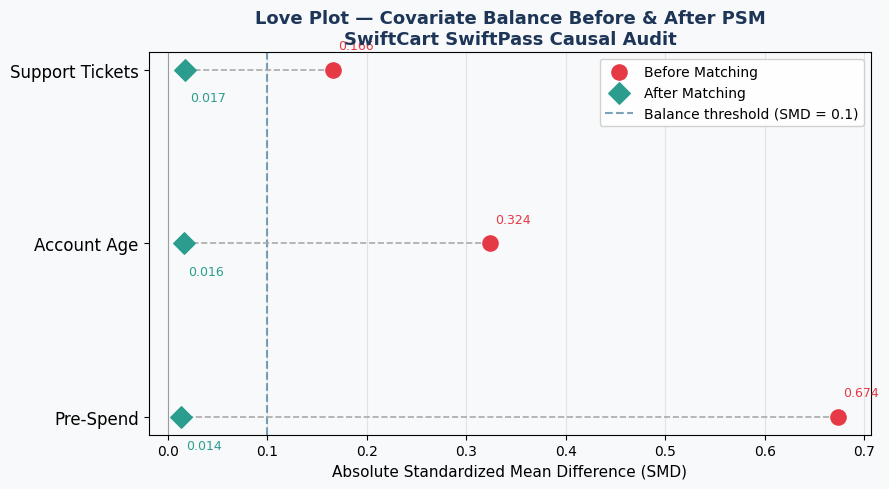


Theoretical Visual Evidence for Successful Bias Mitigation:
─────────────────────────────────────────────────────────────
A Love Plot proves selection bias was eliminated when ALL covariates
satisfy two visual conditions after matching:

1. All green diamonds (post-match) fall LEFT of the SMD = 0.1 threshold.
   This is the standard econometric benchmark for "negligible imbalance."
   Any covariate still exceeding 0.1 signals residual confounding.

2. Every arrow points LEFT — each covariate's SMD must decrease after
   matching. A rightward shift would indicate the matching made balance
   worse, invalidating the counterfactual.

If both conditions hold across all covariates, the matched treated and
control groups are statistically exchangeable on observables, meaning
the ATT can be interpreted as a true causal effect rather than a
correlation driven by self-selection.



In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# ── Load data ──────────────────────────────────────────────────────────────────
data = np.genfromtxt('swiftcart_loyalty.csv', delimiter=',', skip_header=1)

subscriber      = data[:, 0]
pre_spend       = data[:, 1]
account_age     = data[:, 2]
support_tickets = data[:, 3]
post_spend      = data[:, 4]

X = np.column_stack([pre_spend, account_age, support_tickets])

# ── PSM (from Step 3.2) ────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000)
lr.fit(X, subscriber)
propensity_scores = lr.predict_proba(X)[:, 1]

treated_idx = np.where(subscriber == 1)[0]
control_idx = np.where(subscriber == 0)[0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(propensity_scores[control_idx].reshape(-1, 1))
_, indices = nn.kneighbors(propensity_scores[treated_idx].reshape(-1, 1))
matched_control_idx = control_idx[indices.flatten()]

# ── Build dataframes for Love Plot ────────────────────────────────────────────
cols = ['pre_spend', 'account_age', 'support_tickets']

df_unmatched = pd.DataFrame(
    np.column_stack([X, subscriber]),
    columns=cols + ['subscriber']
)

df_matched = pd.concat([
    pd.DataFrame(X[treated_idx],         columns=cols).assign(subscriber=1),
    pd.DataFrame(X[matched_control_idx], columns=cols).assign(subscriber=0)
], ignore_index=True)

# ── Standardized Mean Difference function ─────────────────────────────────────
def compute_smd(df, covariates):
    smds = {}
    for col in covariates:
        treated_vals = df.loc[df['subscriber'] == 1, col]
        control_vals = df.loc[df['subscriber'] == 0, col]
        pooled_std   = np.sqrt((treated_vals.var() + control_vals.var()) / 2)
        smds[col]    = abs(treated_vals.mean() - control_vals.mean()) / pooled_std
    return smds

smd_before = compute_smd(df_unmatched, cols)
smd_after  = compute_smd(df_matched,   cols)

# ── Love Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

y_pos    = np.arange(len(cols))
labels   = ['Pre-Spend', 'Account Age', 'Support Tickets']

ax.scatter([smd_before[c] for c in cols], y_pos,
           color='#E63946', s=120, zorder=5, label='Before Matching')
ax.scatter([smd_after[c]  for c in cols], y_pos,
           color='#2A9D8F', s=120, marker='D', zorder=5, label='After Matching')

for i, col in enumerate(cols):
    ax.plot([smd_before[col], smd_after[col]], [i, i],
            color='#aaa', linewidth=1.2, linestyle='--', zorder=3)

ax.axvline(0.1, color='#457B9D', linewidth=1.5, linestyle='--', alpha=0.7,
           label='Balance threshold (SMD = 0.1)')
ax.axvline(0.0, color='#333',    linewidth=0.8, alpha=0.4)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Absolute Standardized Mean Difference (SMD)', fontsize=11)
ax.set_title('Love Plot — Covariate Balance Before & After PSM\nSwiftCart SwiftPass Causal Audit',
             fontsize=13, fontweight='bold', color='#1D3557')
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis='x', alpha=0.3)

for i, col in enumerate(cols):
    ax.text(smd_before[col] + 0.005, i + 0.12, f"{smd_before[col]:.3f}",
            color='#E63946', fontsize=9)
    ax.text(smd_after[col]  + 0.005, i - 0.18, f"{smd_after[col]:.3f}",
            color='#2A9D8F', fontsize=9)

plt.tight_layout()
plt.show()

# ── Theoretical evaluation ────────────────────────────────────────────────────
print("""
Theoretical Visual Evidence for Successful Bias Mitigation:
─────────────────────────────────────────────────────────────
A Love Plot proves selection bias was eliminated when ALL covariates
satisfy two visual conditions after matching:

1. All green diamonds (post-match) fall LEFT of the SMD = 0.1 threshold.
   This is the standard econometric benchmark for "negligible imbalance."
   Any covariate still exceeding 0.1 signals residual confounding.

2. Every arrow points LEFT — each covariate's SMD must decrease after
   matching. A rightward shift would indicate the matching made balance
   worse, invalidating the counterfactual.

If both conditions hold across all covariates, the matched treated and
control groups are statistically exchangeable on observables, meaning
the ATT can be interpreted as a true causal effect rather than a
correlation driven by self-selection.
""")